In [1]:
import os, warnings
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from PIL import Image

warnings.filterwarnings("ignore")

In [2]:
DATA_DIR = r"D:\majorprojectdataset\ISL_CSLRT_Corpus\ISL_CSLRT_Corpus\Frames_Word_Level"
IMG_SIZE = 160
BATCH_SIZE = 16

EPOCHS = 40        # 🔥 more learning
LR = 5e-5          # 🔥 better stability
PATIENCE = 7       # 🔥 early stopping
SAVE_PATH = "mobilenet_model.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [3]:
classes = sorted([d for d in os.listdir(DATA_DIR)
                  if os.path.isdir(os.path.join(DATA_DIR, d))])

label_map = {cls: idx for idx, cls in enumerate(classes)}
idx2word = {v: k for k, v in label_map.items()}
NUM_CLASSES = len(classes)

all_paths, all_labels = [], []

for cls in classes:
    cls_dir = os.path.join(DATA_DIR, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith((".jpg",".jpeg",".png")):
            all_paths.append(os.path.join(cls_dir, f))
            all_labels.append(label_map[cls])

In [4]:
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [5]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    all_paths, all_labels, test_size=0.30,
    stratify=all_labels, random_state=42
)

X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50,
    stratify=y_tmp, random_state=42
)

In [6]:
class ISLDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), self.labels[i]

In [7]:
train_loader = DataLoader(ISLDataset(X_tr, y_tr, train_tfm),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

val_loader = DataLoader(ISLDataset(X_val, y_val, val_tfm),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_loader = DataLoader(ISLDataset(X_te, y_te, val_tfm),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [8]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# Freeze all layers first
for param in model.features.parameters():
    param.requires_grad = False

# 🔥 Unfreeze last few layers (VERY IMPORTANT)
for param in model.features[-3:].parameters():
    param.requires_grad = True

# Replace classifier
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(DEVICE)

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [10]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    loss_sum, correct, total = 0, 0, 0

    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        if train:
            optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        if train:
            loss.backward()
            optimizer.step()

        loss_sum += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    return loss_sum/total, correct/total

In [11]:
best_acc = 0
no_improve = 0

for ep in range(EPOCHS):
    print(f"\nEpoch {ep+1}/{EPOCHS}")

    # 🔥 Gradual Unfreezing (BOOST ACCURACY)
    if ep == 10:
        print("🔓 Unfreezing more layers")
        for param in model.features[-5:].parameters():
            param.requires_grad = True

    tl, ta = run_epoch(train_loader, True)
    vl, va = run_epoch(val_loader, False)

    scheduler.step()

    print(f"Train Acc: {ta:.4f} | Val Acc: {va:.4f}")

    # Save best model
    if va > best_acc:
        best_acc = va
        torch.save(model.state_dict(), SAVE_PATH)
        print("✅ Best Model Saved")
        no_improve = 0
    else:
        no_improve += 1

    # Backup save
    torch.save(model.state_dict(), "last_model.pth")

    # 🔥 Early stopping
    if no_improve >= PATIENCE:
        print("⛔ Early stopping triggered")
        break

print("\n🏆 Best Validation Accuracy:", best_acc)


Epoch 1/40


100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [00:46<00:00,  2.30it/s]


Train Acc: 0.0717 | Val Acc: 0.2915
✅ Best Model Saved

Epoch 2/40


100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [00:35<00:00,  3.04it/s]


Train Acc: 0.2952 | Val Acc: 0.5216
✅ Best Model Saved

Epoch 3/40


...

Train Acc: 0.9152 | Val Acc: 0.8563
✅ Best Model Saved

Epoch 39/40


100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [00:35<00:00,  2.98it/s]


Train Acc: 0.9137 | Val Acc: 0.8516

Epoch 40/40


100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [00:35<00:00,  2.99it/s]

Train Acc: 0.9102 | Val Acc: 0.8505

🏆 Best Validation Accuracy: 0.8563084112149533


In [12]:
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

correct, total = 0, 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.842873831775701


<Figure size 1000x1000 with 0 Axes>

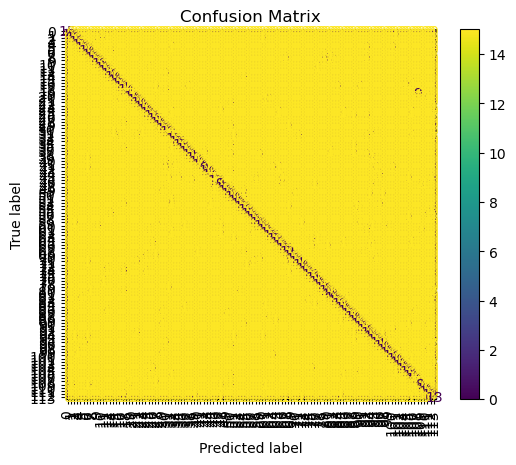

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        outputs = model(imgs)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(10,10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()